<a href="https://colab.research.google.com/github/wvb20/cv-face-alignment/blob/main/notebooks/03_cnn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# === Cell 1: Bootstrap — local or Colab ===
import os, subprocess, sys, time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader

try:
    import google.colab  # type: ignore
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    REPO_PATH = '/content/cv-face-alignment'
    if not os.path.exists(REPO_PATH):
        subprocess.run(
            ['git', 'clone', 'https://github.com/wvb20/cv-face-alignment.git', REPO_PATH],
            check=True,
        )
    else:
        subprocess.run(['git', '-C', REPO_PATH, 'pull'], check=True)
else:
    start = Path.cwd().resolve()
    for candidate in (start, *start.parents):
        if (candidate / 'src' / 'config.py').exists():
            REPO_PATH = str(candidate)
            break
    else:
        raise RuntimeError(
            'Could not find the repo root. Start Jupyter from the repository or set CV_FACE_ALIGNMENT_REPO_ROOT.'
        )

if REPO_PATH not in sys.path:
    sys.path.insert(0, REPO_PATH)

try:
    get_ipython().run_line_magic('load_ext', 'autoreload')
    get_ipython().run_line_magic('autoreload', '2')
except Exception:
    pass

from src.runtime import configure_notebook_runtime
runtime = configure_notebook_runtime(REPO_PATH)
from src import config, data, evaluate, features, models, visualise, io

print('✓ Setup complete')
runtime_label = 'Colab' if runtime.in_colab else 'Local'
print(f'Runtime:   {runtime_label}')
print(f'Repo:      {runtime.repo_root}')
print(f'Workspace: {runtime.workspace_dir}')

if hasattr(torch, 'set_float32_matmul_precision'):
    torch.set_float32_matmul_precision('high')

if torch.cuda.is_available():
    device = torch.device('cuda')
elif torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')

print(f'Device: {device}')
if device.type == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')
elif device.type == 'mps':
    print('GPU: Apple Metal (MPS)')
elif hasattr(torch.backends, 'mps'):
    print(f"MPS built: {torch.backends.mps.is_built()}, available: {torch.backends.mps.is_available()}")

✓ Setup complete
Runtime:   Local
Repo:      /Users/willvaughn/Developer/cv-face-alignment
Workspace: /Users/willvaughn/Developer/cv-face-alignment
Device: mps
GPU: Apple Metal (MPS)


In [2]:
# === Cell 2: Load data, build train/val datasets ===
images, points = data.load_train()
train_idx, val_idx = data.get_split()

X_train, y_train = images[train_idx], points[train_idx]
X_val,   y_val   = images[val_idx],   points[val_idx]

train_ds = data.FaceLandmarksDataset(X_train, y_train, augment=True)
val_ds   = data.FaceLandmarksDataset(X_val,   y_val,   augment=False)

train_batch_size = 16 if device.type == 'mps' else 32
eval_batch_size = 32 if device.type == 'mps' else 64

if device.type == 'cuda':
    loader_kwargs = dict(num_workers=2, pin_memory=True, persistent_workers=True)
elif device.type == 'mps':
    # On Apple Silicon, Python/OpenCV-heavy preprocessing is often faster
    # in-process than via spawned workers, and pinned memory is CUDA-only.
    loader_kwargs = dict(num_workers=0, pin_memory=False)
else:
    loader_kwargs = dict(num_workers=min(4, os.cpu_count() or 1), pin_memory=False,
                         persistent_workers=True)

train_loader = DataLoader(train_ds, batch_size=train_batch_size, shuffle=True,
                          **loader_kwargs)
val_loader   = DataLoader(val_ds,   batch_size=eval_batch_size, shuffle=False,
                          **loader_kwargs)

print(f'Train: {len(train_ds)} images ({len(train_loader)} batches)')
print(f'Val:   {len(val_ds)} images ({len(val_loader)} batches)')
print(f'Loader settings: {loader_kwargs}')

# Quick sanity check — pull one batch and verify shapes
img_batch, pt_batch = next(iter(train_loader))
print(f'\nOne batch:')
print(f'  Images: {img_batch.shape}, dtype={img_batch.dtype}')
print(f'  Points: {pt_batch.shape}, dtype={pt_batch.dtype}')
print(f'  Image range: [{img_batch.min():.2f}, {img_batch.max():.2f}]  (post-normalisation)')
print(f'  Point range: [{pt_batch.min():.2f}, {pt_batch.max():.2f}]  (should be ~[-1, 1])')

Train: 2390 images (75 batches)
Val:   421 images (7 batches)
Loader settings: {'num_workers': 0, 'pin_memory': False}

One batch:
  Images: torch.Size([32, 3, 256, 256]), dtype=torch.float32
  Points: torch.Size([32, 5, 2]), dtype=torch.float32
  Image range: [-1.54, 2.59]  (post-normalisation)
  Point range: [-0.53, 0.55]  (should be ~[-1, 1])


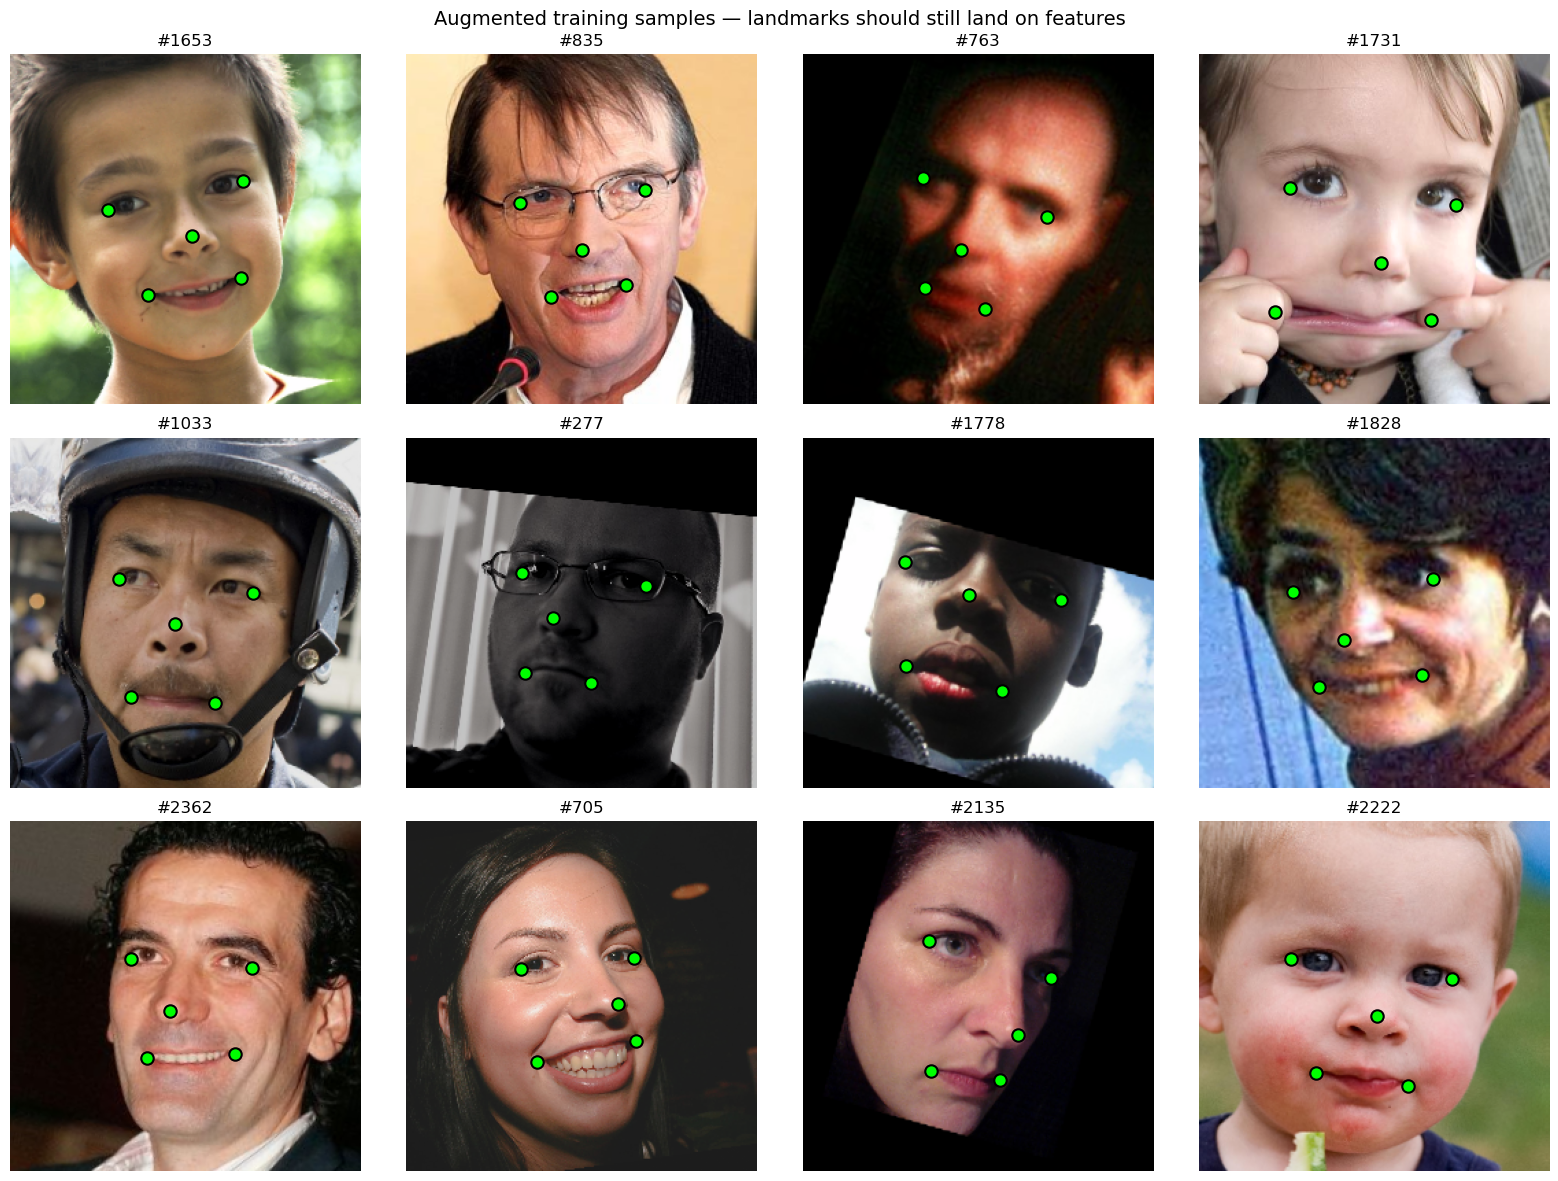

In [3]:
# === Cell 3: Visualise augmented batches to verify landmarks track correctly ===
# Make a fresh dataset so we can call __getitem__ multiple times to see different augs
aug_ds = data.FaceLandmarksDataset(X_train, y_train, augment=True)

fig, axes = plt.subplots(3, 4, figsize=(16, 12))
np.random.seed(0)
torch.manual_seed(0)

for ax in axes.flat:
    idx = np.random.randint(len(aug_ds))
    img_t, pt_t = aug_ds[idx]
    # De-normalise image for display
    img_disp = img_t.numpy().transpose(1, 2, 0)
    for c in range(3):
        img_disp[..., c] = img_disp[..., c] * config.NORMALISE_STD[c] + config.NORMALISE_MEAN[c]
    img_disp = np.clip(img_disp, 0, 1)
    # De-normalise points
    pts_disp = models.points_to_pixels(pt_t.numpy(), config.IMAGE_SIZE)

    ax.imshow(img_disp)
    ax.scatter(pts_disp[:, 0], pts_disp[:, 1], s=80, c='lime',
               edgecolors='black', linewidths=1.5)
    ax.set_title(f'#{idx}')
    ax.axis('off')

fig.suptitle('Augmented training samples — landmarks should still land on features',
             fontsize=14)
fig.tight_layout()
plt.savefig(f'{config.FIGURES_DIR}/09_augmentation_check.png',
            dpi=120, bbox_inches='tight')
plt.show()

In [4]:
# === Cell 4: Training and validation step functions ===

def train_one_epoch(model, loader, optimiser, criterion, device):
    model.train()
    total_loss = 0.0
    for imgs, pts in loader:
        imgs = imgs.to(device, non_blocking=True)
        pts  = pts.to(device, non_blocking=True)

        optimiser.zero_grad(set_to_none=True)
        preds = model(imgs)
        if not torch.isfinite(preds).all():
            raise RuntimeError('Non-finite predictions encountered during training.')
        loss = criterion(preds, pts)
        if not torch.isfinite(loss):
            raise RuntimeError('Non-finite loss encountered during training.')
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimiser.step()

        total_loss += loss.item() * imgs.size(0)
    return total_loss / len(loader.dataset)


@torch.no_grad()
def evaluate_model(model, loader, criterion, device):
    """Returns (mean_loss, all_preds_pixels, all_targets_pixels)."""
    model.eval()
    total_loss = 0.0
    all_preds, all_gts = [], []
    for imgs, pts in loader:
        imgs = imgs.to(device, non_blocking=True)
        pts  = pts.to(device, non_blocking=True)

        preds = model(imgs)
        if not torch.isfinite(preds).all():
            raise RuntimeError('Non-finite predictions encountered during evaluation.')
        loss = criterion(preds, pts)
        total_loss += loss.item() * imgs.size(0)

        # Convert back to pixel coordinates for NME calc
        preds_px = models.points_to_pixels(preds.cpu().numpy(),
                                            config.IMAGE_SIZE)
        gts_px   = models.points_to_pixels(pts.cpu().numpy(),
                                            config.IMAGE_SIZE)
        all_preds.append(preds_px)
        all_gts.append(gts_px)

    return (total_loss / len(loader.dataset),
            np.concatenate(all_preds),
            np.concatenate(all_gts))

In [5]:
# === Diagnostic: check parameter dtypes ===
import torch
from src import models

m = models.LandmarkCNN(n_landmarks=5, dropout=0.0)
print('Parameter dtypes (should all be torch.float32):')
bad = []
for name, p in m.named_parameters():
    if p.dtype != torch.float32:
        bad.append((name, p.dtype))
        print(f'  ❌ {name}: {p.dtype}')
    # Show the final layer specifically
    if 'head.4' in name or name.endswith('bias') and 'head' in name:
        print(f'  → {name}: dtype={p.dtype}, shape={tuple(p.shape)}')

if bad:
    print(f'\n{len(bad)} parameter(s) have wrong dtype.')
else:
    print('\nAll parameters are float32.')

# Also check the data tensor of the final bias specifically
final_bias = m.head[-1].bias
print(f'\nFinal layer bias: dtype={final_bias.dtype}, '
      f'data dtype={final_bias.data.dtype}')
print(f'Bias values: {final_bias.data.tolist()}')

Parameter dtypes (should all be torch.float32):
  → spatial_head.0.bias: dtype=torch.float32, shape=(64,)
  → spatial_head.1.bias: dtype=torch.float32, shape=(64,)
  → head.1.bias: dtype=torch.float32, shape=(256,)
  → head.4.weight: dtype=torch.float32, shape=(10, 256)
  → head.4.bias: dtype=torch.float32, shape=(10,)

All parameters are float32.

Final layer bias: dtype=torch.float32, data dtype=torch.float32
Bias values: [-0.375, -0.18700000643730164, 0.375, -0.19499999284744263, 0.00800000037997961, 0.11699999868869781, -0.22699999809265137, 0.382999986410141, 0.25, 0.375]


In [ ]:
# === Cell 5: Train CNN ===
torch.manual_seed(config.RANDOM_SEED)

model = models.LandmarkCNN(n_landmarks=config.N_LANDMARKS, dropout=0.3).to(device)
n_params = sum(p.numel() for p in model.parameters())
print(f'Model: LandmarkCNN, {n_params:,} parameters')

# Smooth L1 (Huber) — more robust than MSE to outlier landmarks
criterion = nn.SmoothL1Loss()

# Switch to MSE loss - Smooth L1 resulted in suboptimal outcomes
#criterion = nn.MSELoss()

learning_rate = 3e-4 if device.type == 'mps' else 1e-3
optimiser = torch.optim.Adam(model.parameters(), lr=learning_rate, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimiser, mode='min', factor=0.5, patience=5
)

N_EPOCHS = 60
best_val_nme = float('inf')
best_epoch = -1
history = {'train_loss': [], 'val_loss': [], 'val_nme': []}

ckpt_path = f'{config.CHECKPOINTS_DIR}/landmark_cnn_spatial_best.pt'

print(f'\nTraining for up to {N_EPOCHS} epochs on {device}...')
print(f'Initial learning rate: {learning_rate:.0e}')
t_start = time.time()
for epoch in range(1, N_EPOCHS + 1):
    train_loss = train_one_epoch(model, train_loader, optimiser, criterion, device)
    val_loss, val_preds, val_gts = evaluate_model(model, val_loader, criterion, device)
    val_nme = evaluate.nme(val_preds, val_gts)
    val_nme_mean = float(val_nme.mean())

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['val_nme'].append(val_nme_mean)

    # Step on NME, not the tiny normalised regression loss.
    scheduler.step(val_nme_mean)
    current_lr = optimiser.param_groups[0]['lr']

    # Save best checkpoint by val NME
    if val_nme_mean < best_val_nme:
        best_val_nme = val_nme_mean
        best_epoch = epoch
        torch.save({
            'epoch': epoch,
            'model_state': model.state_dict(),
            'val_nme': val_nme_mean,
        }, ckpt_path)
        marker = ' ★ best'
    else:
        marker = ''

    print(f'Epoch {epoch:3d}/{N_EPOCHS} | '
          f'train={train_loss:.4f}  val={val_loss:.4f}  '
          f'val NME={val_nme_mean*100:.2f}%  lr={current_lr:.0e}{marker}')

elapsed = time.time() - t_start
print(f'\nTraining done. Total time: {elapsed/60:.1f} min')
print(f'Best val NME: {best_val_nme*100:.2f}% at epoch {best_epoch}')
print(f'Best checkpoint: {ckpt_path}')

Model: LandmarkCNN, 2,242,730 parameters

Training for up to 60 epochs on mps...


/Users/willvaughn/Developer/cv-face-alignment/src/models.py:239: RuntimeWarning: overflow encountered in multiply
  return norm_points * (image_size / 2) + image_size / 2
/Volumes/DataDrive/conda-envs/ComputerVision/lib/python3.11/site-packages/numpy/linalg/_linalg.py:2803: RuntimeWarning: overflow encountered in multiply
  s = (x.conj() * x).real
/Users/willvaughn/Developer/cv-face-alignment/src/evaluate.py:48: RuntimeWarning: divide by zero encountered in divide
  return per_lm_err.mean(axis=1) / iod                       # (N,)
/Users/willvaughn/Developer/cv-face-alignment/src/evaluate.py:48: RuntimeWarning: invalid value encountered in divide
  return per_lm_err.mean(axis=1) / iod                       # (N,)


Epoch   1/60 | train=7874682919366316032.0000  val=nan  val NME=nan%  lr=1e-03
Epoch   2/60 | train=0.0097  val=5820304816702051583988358885408768.0000  val NME=nan%  lr=1e-03
Epoch   3/60 | train=0.0112  val=11659027487943155456424250804535296.0000  val NME=nan%  lr=1e-03


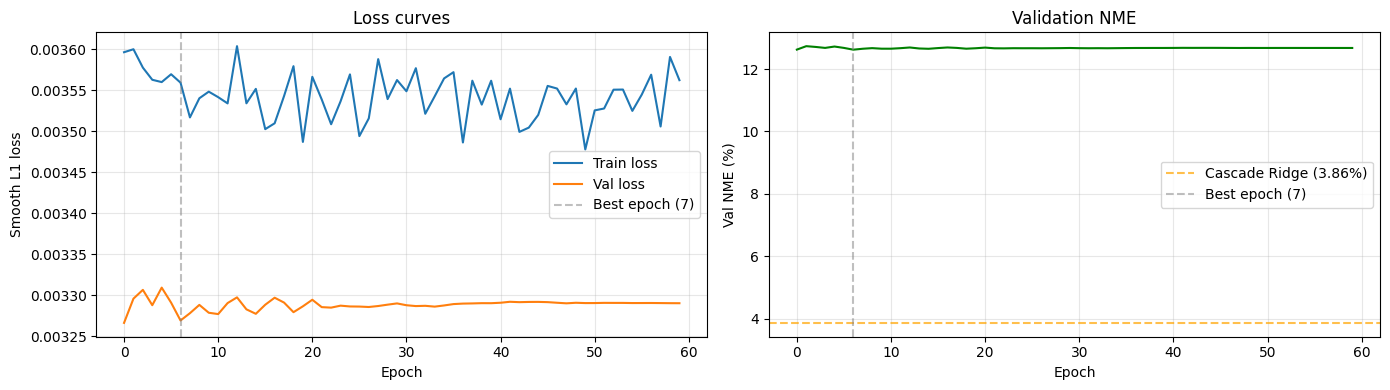

In [ ]:
# === Cell 6: Plot training curves ===
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(history['train_loss'], label='Train loss')
axes[0].plot(history['val_loss'],   label='Val loss')
axes[0].axvline(best_epoch - 1, ls='--', c='grey', alpha=0.5,
                label=f'Best epoch ({best_epoch})')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Smooth L1 loss')
axes[0].set_title('Loss curves')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot([n*100 for n in history['val_nme']], color='green')
axes[1].axhline(3.86, ls='--', c='orange', alpha=0.7,
                label='Cascade Ridge (3.86%)')
axes[1].axvline(best_epoch - 1, ls='--', c='grey', alpha=0.5,
                label=f'Best epoch ({best_epoch})')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Val NME (%)')
axes[1].set_title('Validation NME')
axes[1].legend()
axes[1].grid(alpha=0.3)

fig.tight_layout()
plt.savefig(f'{config.FIGURES_DIR}/10_training_curves.png',
            dpi=120, bbox_inches='tight')
plt.show()

In [ ]:
# === Cell 7: Reload best checkpoint, full evaluation on val ===
ckpt = torch.load(ckpt_path, map_location=device, weights_only=False)
model.load_state_dict(ckpt['model_state'])
print(f'Loaded best checkpoint from epoch {ckpt["epoch"]}')

_, val_preds_cnn, val_gts_check = evaluate_model(
    model, val_loader, criterion, device
)
nme_cnn = evaluate.nme(val_preds_cnn, val_gts_check)

print(f'\nCNN validation results:')
print(f'  NME mean   = {nme_cnn.mean()*100:.2f}%')
print(f'  NME median = {np.median(nme_cnn)*100:.2f}%')
print(f'  Failure rate (>10%) = {evaluate.failure_rate(nme_cnn)*100:.1f}%')

Loaded best checkpoint from epoch 7

CNN validation results:
  NME mean   = 12.62%
  NME median = 11.43%
  Failure rate (>10%) = 60.8%


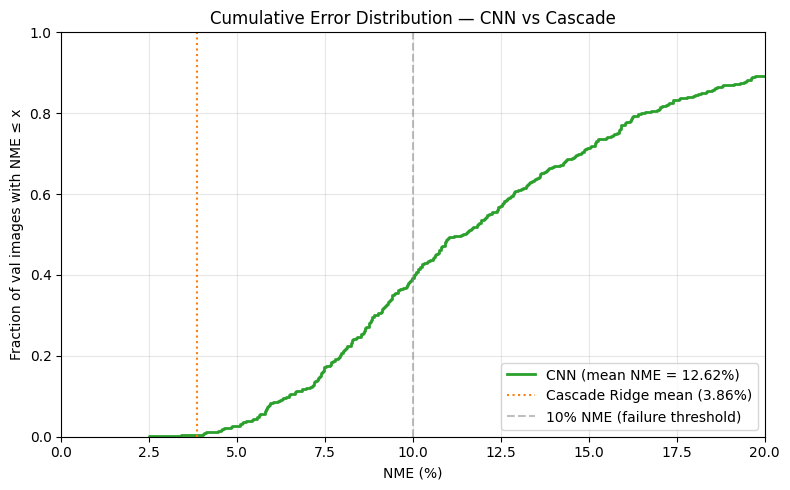


--- Summary ---
  Cascade Ridge: NME = 3.86%, failures = 0.7%
  CNN:           NME = 12.62%, failures = 60.8%


In [ ]:
# === Cell 8: CED comparison vs the cascade baseline ===
# We need the cascade NMEs again — easiest is to re-import them via training
# the cascade quickly OR just reproduce the numbers from notebook 02.
# For now, hardcode them; you can recompute by running 02_baseline_sift.

CASCADE_NME_MEAN   = 3.86 / 100
CASCADE_NME_MEDIAN = 3.44 / 100
CASCADE_FAIL_RATE  = 0.7 / 100

fig, ax = plt.subplots(figsize=(8, 5))

# Re-load the cascade NMEs from disk if you saved them; otherwise just
# annotate them. Simplest approach: rerun cascade in this notebook.
# But we'll plot CNN curve and overlay cascade summary stats:

x_cnn, y_cnn = evaluate.cumulative_error_distribution(nme_cnn)
ax.step(x_cnn * 100, y_cnn,
        label=f'CNN (mean NME = {nme_cnn.mean()*100:.2f}%)',
        color='C2', linewidth=2)

ax.axvline(CASCADE_NME_MEAN * 100, ls=':', c='C1',
           label=f'Cascade Ridge mean ({CASCADE_NME_MEAN*100:.2f}%)')
ax.axvline(10, ls='--', c='grey', alpha=0.5,
           label='10% NME (failure threshold)')

ax.set_xlabel('NME (%)')
ax.set_ylabel('Fraction of val images with NME ≤ x')
ax.set_xlim(0, 20)
ax.set_ylim(0, 1.0)
ax.grid(alpha=0.3)
ax.legend(loc='lower right')
ax.set_title('Cumulative Error Distribution — CNN vs Cascade')
fig.tight_layout()
plt.savefig(f'{config.FIGURES_DIR}/11_ced_cnn_vs_cascade.png',
            dpi=150, bbox_inches='tight')
plt.show()

print(f'\n--- Summary ---')
print(f'  Cascade Ridge: NME = {CASCADE_NME_MEAN*100:.2f}%, '
      f'failures = {CASCADE_FAIL_RATE*100:.1f}%')
print(f'  CNN:           NME = {nme_cnn.mean()*100:.2f}%, '
      f'failures = {evaluate.failure_rate(nme_cnn)*100:.1f}%')

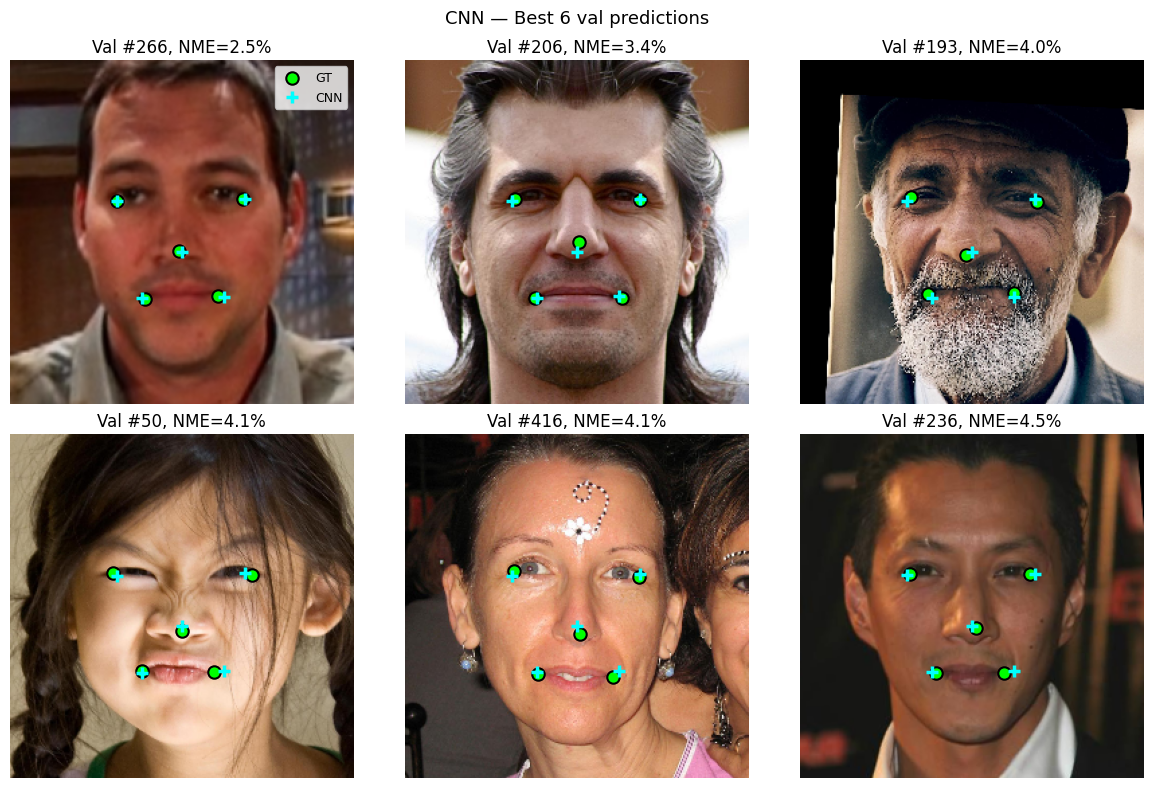

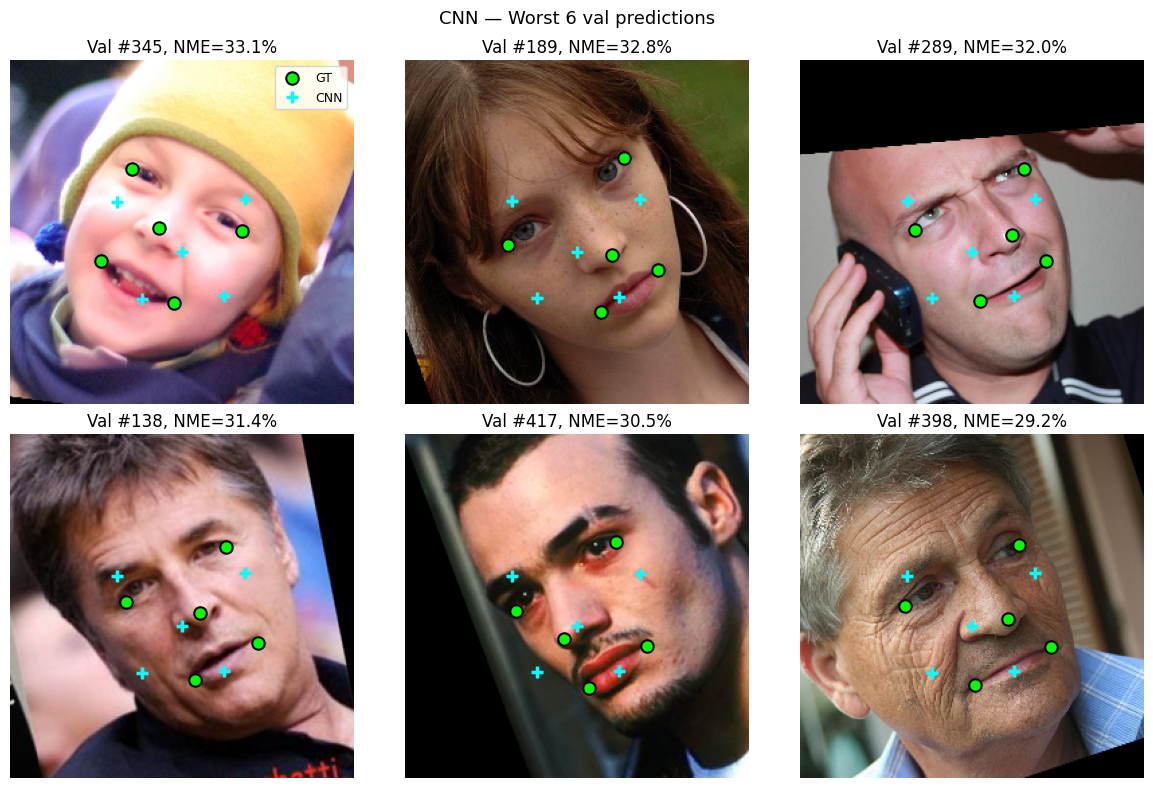

In [ ]:
# === Cell 9: Best-of and worst-of CNN val predictions ===
worst_idx = np.argsort(nme_cnn)[-6:][::-1]
best_idx  = np.argsort(nme_cnn)[:6]

for label, idxs in [('Best 6', best_idx), ('Worst 6', worst_idx)]:
    fig, axes = plt.subplots(2, 3, figsize=(12, 8))
    for ax, i in zip(axes.flat, idxs):
        ax.imshow(X_val[i])
        ax.scatter(y_val[i, :, 0], y_val[i, :, 1],
                   s=80, c='lime', edgecolors='black',
                   linewidths=1.5, label='GT', zorder=4)
        ax.scatter(val_preds_cnn[i, :, 0], val_preds_cnn[i, :, 1],
                   s=80, marker='+', c='cyan',
                   linewidths=2.5, label='CNN', zorder=5)
        ax.set_title(f'Val #{i}, NME={nme_cnn[i]*100:.1f}%')
        ax.axis('off')
    axes[0, 0].legend(loc='upper right', fontsize=9)
    fig.suptitle(f'CNN — {label} val predictions', fontsize=13)
    fig.tight_layout()
    plt.savefig(f'{config.FIGURES_DIR}/12_cnn_{label.replace(" ", "_").lower()}.png',
                dpi=120, bbox_inches='tight')
    plt.show()

In [ ]:
# === Cell 10: Generate CNN test predictions, save as CSV ===
test_images = data.load_test()
print(f'Test set: {test_images.shape}')

# Build a test "dataset" — points are unused but FaceLandmarksDataset needs
# something there. Use zeros; we never look at them.
test_dummy_pts = np.zeros((len(test_images), config.N_LANDMARKS, 2),
                          dtype=np.float32)
test_ds = data.FaceLandmarksDataset(test_images, test_dummy_pts, augment=False)
test_loader = DataLoader(test_ds, batch_size=eval_batch_size, shuffle=False,
                         **loader_kwargs)

model.eval()
all_preds = []
with torch.no_grad():
    for imgs, _ in test_loader:
        imgs = imgs.to(device)
        preds = model(imgs).cpu().numpy()
        all_preds.append(models.points_to_pixels(preds, config.IMAGE_SIZE))
y_pred_test_cnn = np.concatenate(all_preds)
print(f'Predictions shape: {y_pred_test_cnn.shape}')

# Save
output_dir = f'{REPO_PATH}/outputs'
os.makedirs(output_dir, exist_ok=True)
io.save_as_csv(y_pred_test_cnn, location=output_dir)

import shutil
src_csv  = f'{output_dir}/results_task2.csv'
dest_csv = f'{output_dir}/results_task2_cnn.csv'
shutil.copy(src_csv, dest_csv)
workspace_csv = f'{config.DRIVE_PROJECT_DIR}/results_task2_cnn.csv'
shutil.copy(src_csv, workspace_csv)
print(f'\n✓ Saved CNN predictions to:')
print(f'  {dest_csv}')
print(f'  {workspace_csv}  (workspace copy)')

Test set: (554, 256, 256, 3)
Predictions shape: (554, 5, 2)

✓ Saved CNN predictions to:
  /content/cv-face-alignment/outputs/results_task2_cnn.csv
  /content/drive/MyDrive/cv-face-alignment/results_task2_cnn.csv  (Drive backup)


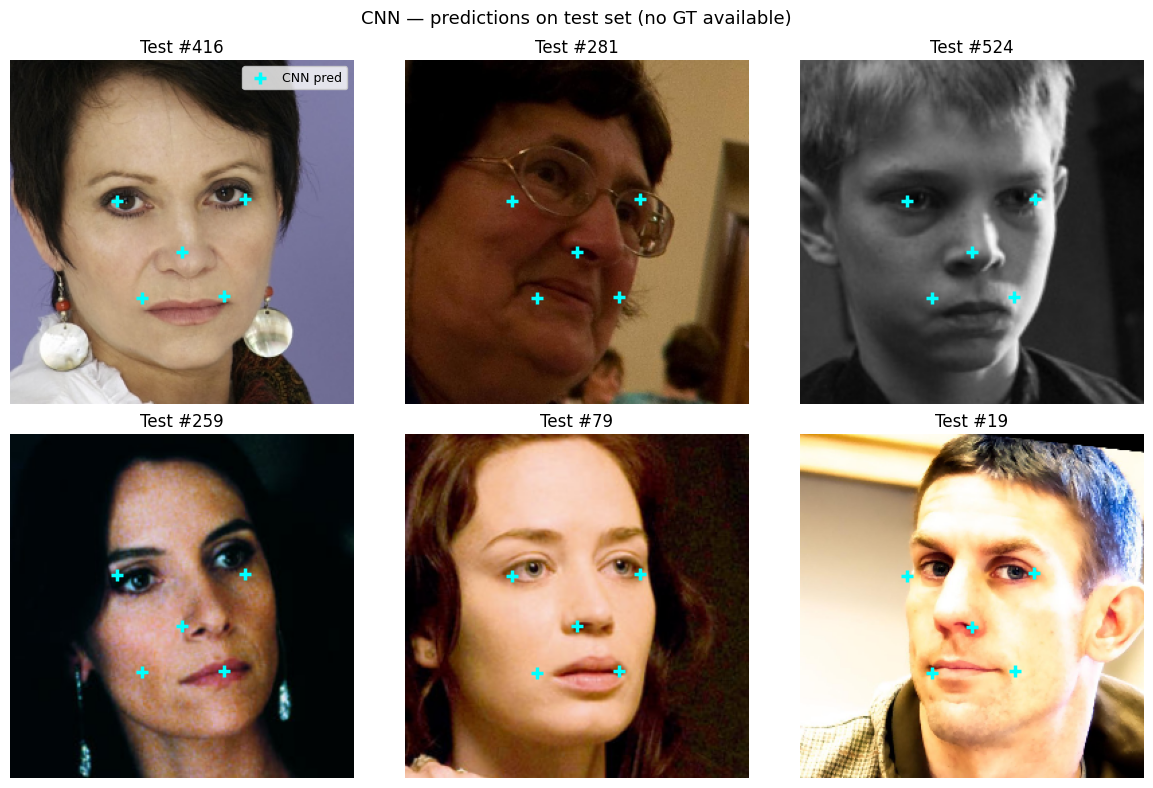

In [ ]:
# === Cell 11: CNN predictions on 6 random test images ===
rng = np.random.default_rng(seed=1)
test_sample = rng.choice(len(test_images), size=6, replace=False)

fig, axes = plt.subplots(2, 3, figsize=(12, 8))
for ax, i in zip(axes.flat, test_sample):
    ax.imshow(test_images[i])
    ax.scatter(y_pred_test_cnn[i, :, 0], y_pred_test_cnn[i, :, 1],
               s=80, marker='+', c='cyan',
               linewidths=2.5, label='CNN pred', zorder=4)
    ax.set_title(f'Test #{i}')
    ax.axis('off')
axes[0, 0].legend(loc='upper right', fontsize=9)
fig.suptitle('CNN — predictions on test set (no GT available)', fontsize=13)
fig.tight_layout()
plt.savefig(f'{config.FIGURES_DIR}/13_cnn_test_predictions.png',
            dpi=120, bbox_inches='tight')
plt.show()

In [ ]:
# === Diagnostics 1: Inspect prediction values ===
# The initial attempt at the CNN produced poor results
# Looking at the predictions, it seems like the model collapsed to
# Using the same predictor for all the images.
print('Per-landmark mean of val_preds_cnn (should look like face landmarks):')
print(val_preds_cnn.mean(axis=0))
print()
print('Per-landmark mean of y_val (ground truth):')
print(y_val.mean(axis=0))
print()
print('Per-image variance of val_preds_cnn (if predictions vary across images):')
# If CNN is predicting the mean for every image, variance should be near 0
print(f'  std across images, x:  {val_preds_cnn[..., 0].std(axis=0)}')
print(f'  std across images, y:  {val_preds_cnn[..., 1].std(axis=0)}')
print()
print('For comparison, std across images for ground truth:')
print(f'  std across images, x:  {y_val[..., 0].std(axis=0)}')
print(f'  std across images, y:  {y_val[..., 1].std(axis=0)}')

Per-landmark mean of val_preds_cnn (should look like face landmarks):
[[ 79.53388 104.67807]
 [174.49907 103.08215]
 [127.55139 142.53491]
 [ 97.84298 176.91743]
 [158.99406 175.69954]]

Per-landmark mean of y_val (ground truth):
[[ 79.94253781 104.62118665]
 [175.98304515 102.73996679]
 [128.63398684 143.43316206]
 [ 99.33566681 176.91448276]
 [160.07837568 175.77260568]]

Per-image variance of val_preds_cnn (if predictions vary across images):
  std across images, x:  [0.03737358 0.07907206 0.01078243 0.12388043 0.17261626]
  std across images, y:  [0.13467577 0.12916024 0.0442806  0.13977386 0.06805934]

For comparison, std across images for ground truth:
  std across images, x:  [ 6.44287854  6.71149717 13.52914273 13.6906659  12.49528494]
  std across images, y:  [ 9.58548871  9.51380454 10.33949281  8.96716736  8.94588103]


In [ ]:
# === Diagnostic 2: Predict 3 specific images, manually compare ===
model.eval()

for label, idx_in_val in [('best #266', 266), ('best #206', 206), ('worst', int(np.argmax(nme_cnn)))]:
    img_t, pt_t = val_ds[idx_in_val]
    pt_t_pixels = models.points_to_pixels(pt_t.numpy(), config.IMAGE_SIZE)

    with torch.no_grad():
        pred_norm = model(img_t.unsqueeze(0).to(device)).cpu().numpy()[0]
    pred_pixels = models.points_to_pixels(pred_norm, config.IMAGE_SIZE)

    err_pixels = np.linalg.norm(pred_pixels - pt_t_pixels, axis=1)
    iod = np.linalg.norm(pt_t_pixels[1] - pt_t_pixels[0])
    nme_manual = err_pixels.mean() / iod

    print(f'\n{label} (val idx={idx_in_val}):')
    print(f'  Stored pred: {val_preds_cnn[idx_in_val].round(1).tolist()}')
    print(f'  Re-predicted: {pred_pixels.round(1).tolist()}')
    print(f'  Stored NME: {nme_cnn[idx_in_val]*100:.1f}%')
    print(f'  Manual NME: {nme_manual*100:.1f}%')
    print(f'  GT:         {pt_t_pixels.round(1).tolist()}')


best #266 (val idx=266):
  Stored pred: [[79.5999984741211, 104.5], [174.60000610351562, 103.30000305175781], [127.5, 142.5], [97.69999694824219, 176.6999969482422], [158.6999969482422, 175.8000030517578]]
  Re-predicted: [[79.5999984741211, 104.5], [174.60000610351562, 103.30000305175781], [127.5, 142.5], [97.69999694824219, 176.6999969482422], [158.6999969482422, 175.8000030517578]]
  Stored NME: 2.5%
  Manual NME: 2.5%
  GT:         [[79.0, 104.0999984741211], [173.10000610351562, 103.0], [125.30000305175781, 141.60000610351562], [100.4000015258789, 177.3000030517578], [154.39999389648438, 175.3000030517578]]

best #206 (val idx=206):
  Stored pred: [[79.5, 104.80000305175781], [174.39999389648438, 102.9000015258789], [127.5, 142.60000610351562], [98.0, 177.10000610351562], [159.1999969482422, 175.60000610351562]]
  Re-predicted: [[79.5, 104.80000305175781], [174.39999389648438, 102.9000015258789], [127.5, 142.60000610351562], [98.0, 177.10000610351562], [159.1999969482422, 175.600